In [1]:
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/analysing_dpa_results')
import create_results_array_zarr as arr_zrr
import importlib

device: cpu


In [2]:
importlib.reload(arr_zrr)
dpa_t_samples_raw, dpa_t_samples, t_arr_raw, t_arr_restored = arr_zrr.create_array()

device: cpu
torch.Size([476900, 1024])
Mask entire created
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
Now saving arrays ...


In [5]:
len(dpa_t_samples_raw)
print(dpa_t_samples_raw[0].shape)

torch.Size([64000, 648])


In [28]:
import utils as ut
importlib.reload(ut)
import json
import xarray as xr

### get mask ###
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)

ds = xr.open_dataset(settings['dataset_trefht'])
x_entire = ut.data_to_torch(ds, "TREFHT")
x_entire_reduced, mask = ut.remove_nan_columns(x_entire)
#################
# for test coordinates
ds_test = ds.isel(time=slice(-64000, 476900))
ds_test



torch.Size([476900, 1024])


<xarray.Dataset> Size: 263MB
Dimensions:  (lat: 32, lon: 32, time: 64000)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 262MB ...

In [31]:
importlib.reload(ut)

predicts_path = "/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/"
tensor_list, stacked, stacked_reshaped, ds = ut.load_dpa_arrays(predicts_path, mask, ds_test)

print(stacked.shape)
print(stacked_reshaped.shape)
ds



Now loading DPA ensemble
Tensor list length: 2
Tensor list elements shape: torch.Size([64000, 1024])


/home/sc.uni-leipzig.de/fl53wumy/.conda/envs/dpa/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


torch.Size([2, 64000, 1024])
torch.Size([2, 64000, 32, 32])


<xarray.Dataset> Size: 525MB
Dimensions:          (ensemble_member: 2, time: 64000, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 16B 1 2
  * time             (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 524MB nan ... ...

In [25]:
ds = xr.Dataset({
    "TREFHT": xr.DataArray(stacked_reshaped.detach().numpy(), dims=("ensemble_member", "time", "lat", "lon"),
                        coords={
                                "ensemble_member": np.arange(1,3),
                                "time": ds_test.time,
                                "lat": ds_test.lat,
                                "lon": ds_test.lon
                            },)
    })
ds
#ds.to_zarr("data.zarr", consolidated=True)

<xarray.Dataset> Size: 525MB
Dimensions:          (ensemble_member: 2, time: 64000, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 16B 1 2
  * time             (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 524MB nan ... ...

In [22]:
import numpy as np
np.arange(1,98)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97])

In [10]:
stacked_reshaped = stacked.reshape(2, 64000, 32, 32)
stacked_reshaped.shape

torch.Size([2, 64000, 32, 32])

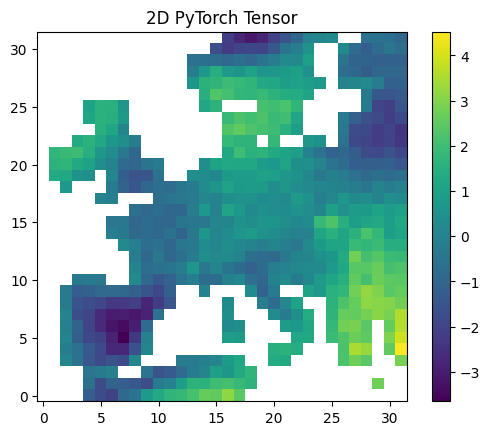

In [17]:
import matplotlib.pyplot as plt
plt.imshow(stacked_reshaped[0,10000,:,:].detach().numpy(), cmap='viridis', origin = 'lower')
plt.colorbar()  # Optional: show color scale
plt.title("2D PyTorch Tensor")
plt.show()